In [ ]:

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
import joblib
try:
    import xgboost as xgb
except Exception:
    xgb = None
try:
    import lightgbm as lgb
except Exception:
    lgb = None

# plotting defaults
%matplotlib inline
sns.set(style="whitegrid")


In [25]:
%pip install -q datasets

Note: you may need to restart the kernel to use updated packages.


In [ ]:
if os.path.exists("train.csv"):
    df = pd.read_csv("train.csv", header=None)
    if df.shape[1] == 3:
        df.columns = ["label", "title", "description"]
    else:
        print("train.csv has unexpected shape:", df.shape)
        display(df.head())
else:
    from datasets import load_dataset
    ds = load_dataset("ag_news")
    train = pd.DataFrame(ds["train"])
    test = pd.DataFrame(ds["test"])
    # HF 'ag_news' gives 'text' and 'label' — use text as title, empty description
    train['title'] = train['text']
    train['description'] = ''
    test['title'] = test['text']
    test['description'] = ''
    df = pd.concat([train[['label','title','description']], test[['label','title','description']]]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
print("Label distribution:")
print(df['label'].value_counts().sort_index())


README.md: 0.00B [00:00, ?B/s]

c:\Users\hazem\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:159: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\hazem\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset shape: (127600, 3)


,label,title,description
0,2,Wall St. Bears Claw Back Into the Black (Reute...,
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,
4,2,"Oil prices soar to all-time record, posing new...",


Label distribution:
0    31900
1    31900
2    31900
3    31900
Name: label, dtype: int64



--- Label 0 example ---
Title: Japan death toll from Meari rises to 19, 8 missing The death toll from a tropical storm buffeting Japan rose yesterday to 19 after searchers found more victims, including two men buried inside their h
Description: 

--- Label 1 example ---
Title: He's a fast learner FOXBOROUGH -- For a long time yesterday the men and women huddled four rows deep around Bethel Johnson's locker knew what Terreal Bierria felt like 45 minutes earlier. Bethel Johns
Description: 

--- Label 2 example ---
Title: The dollar #39;s decline is not yet cause for alarm James K. Galbraith is a professor at the LBJ School of Public Affairs at the University of Texas at Austin and a senior scholar at the Levy Economic
Description: 

--- Label 3 example ---
Title: ATI Xpress 200 Review November 08, 2004 - AnandTech have slapped up a great feature and review on ATI #39;s new chipset for AMD processors, which seems to give Nvidia a run for their money.
Description: 


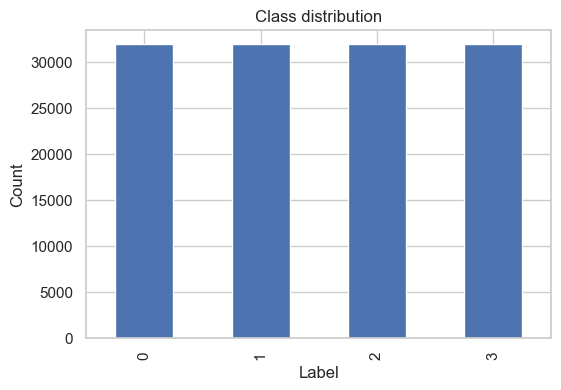

In [3]:
# Show some examples per class
for lab in sorted(df['label'].unique()):
    print(f"\n--- Label {lab} example ---")
    ex = df[df['label']==lab].sample(1).iloc[0]
    print("Title:", ex['title'][:200])
    print("Description:", ex['description'][:200])

# Bar plot of label counts
plt.figure(figsize=(6,4))
df['label'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()


In [5]:
# Define a simple text preprocessing function
def preprocess_text(text):
	# Lowercase
	text = text.lower()
	# Remove non-alphabetic characters
	text = re.sub(r'[^a-z\s]', '', text)
	# Tokenize
	tokens = text.split()
	# Remove stopwords
	stop_words = set(stopwords.words('english'))
	tokens = [w for w in tokens if w not in stop_words]
	# Lemmatize
	lemmatizer = WordNetLemmatizer()
	tokens = [lemmatizer.lemmatize(w) for w in tokens]
	return ' '.join(tokens)

tqdm.pandas()
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')
df['clean_text'] = (df['title'] + " " + df['description']).progress_map(preprocess_text)
display(df[['label','title','clean_text']].head())


  0%|          | 0/127600 [00:00<?, ?it/s]

,label,title,clean_text
0,2,Wall St. Bears Claw Back Into the Black (Reute...,wall st bear claw back black reuters reuters s...
1,2,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle look toward commercial aerospace reute...
2,2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stock outlook reuters reuter...
3,2,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halt oil export main southern pipeline re...
4,2,"Oil prices soar to all-time record, posing new...",oil price soar alltime record posing new menac...


In [6]:
X = df['clean_text']
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (102080,) Test: (25520,)


In [7]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape:", X_train_tfidf.shape)


TF-IDF shape: (102080, 5000)


LogReg Accuracy: 0.9101097178683386
              precision    recall  f1-score   support

           0     0.9205    0.9016    0.9109      6380
           1     0.9506    0.9749    0.9626      6380
           2     0.8804    0.8859    0.8831      6380
           3     0.8881    0.8781    0.8830      6380

    accuracy                         0.9101     25520
   macro avg     0.9099    0.9101    0.9099     25520
weighted avg     0.9099    0.9101    0.9099     25520



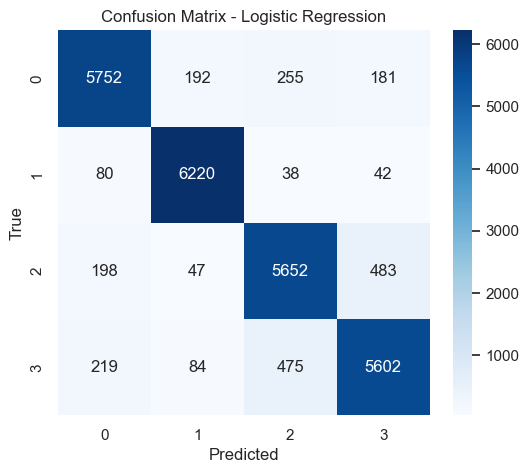

In [8]:
lr = LogisticRegression(max_iter=300, n_jobs=-1, random_state=42)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

print("LogReg Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [9]:
models = {
    "LinearSVC": LinearSVC(max_iter=5000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
}

results = {}
for name, model in models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    results[name] = {"model": model, "accuracy": acc}
    print(name, "accuracy:", acc)

# include LogisticRegression result too
results['LogisticRegression'] = {"model": lr, "accuracy": accuracy_score(y_test, y_pred)}

# Summary table
pd.DataFrame({k:{"accuracy":v["accuracy"]} for k,v in results.items()}).T.sort_values('accuracy', ascending=False)



Training LinearSVC ...


c:\Users\hazem\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


LinearSVC accuracy: 0.9096003134796238

Training RandomForest ...
RandomForest accuracy: 0.8882053291536051


,accuracy
LogisticRegression,0.910110
LinearSVC,0.909600
RandomForest,0.888205


In [10]:
if xgb is not None:
    print("Training XGBoost (sklearn API)...")
    xg = xgb.XGBClassifier(tree_method='hist', use_label_encoder=False, eval_metric='mlogloss', random_state=42)
    xg.fit(X_train_tfidf, y_train)
    print("XGBoost acc:", accuracy_score(y_test, xg.predict(X_test_tfidf)))

if lgb is not None:
    print("Training LightGBM (sklearn API)...")
    lg = lgb.LGBMClassifier(random_state=42)
    lg.fit(X_train_tfidf, y_train)
    print("LightGBM acc:", accuracy_score(y_test, lg.predict(X_test_tfidf)))


Training XGBoost (sklearn API)...


c:\Users\hazem\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:07:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost acc: 0.8905564263322884
Training LightGBM (sklearn API)...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.762895 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 465025
[LightGBM] [Info] Number of data points in the train set: 102080, number of used features: 5000
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
LightGBM acc: 0.898628526645768


In [11]:
# Works for models with coef_ (LogReg, LinearSVC)
def show_top_features(clf, vec, class_idx, top_n=20):
    feat_names = vec.get_feature_names_out()
    coefs = clf.coef_[class_idx]
    top_idxs = np.argsort(coefs)[-top_n:][::-1]
    top_feats = [(feat_names[i], coefs[i]) for i in top_idxs]
    return top_feats

# Example for LogisticRegression:
for i in range(len(lr.classes_)):
    print(f"\nTop words for class {i}:")
    print(show_top_features(lr, vectorizer, i, top_n=15))



Top words for class 0:
[('iraq', 5.611599359614859), ('iraqi', 5.015542950883155), ('afp', 4.835268296308175), ('canadian press', 4.8277707008379895), ('athens greece', 4.3922842063596494), ('hostage', 4.285020349444154), ('afp afp', 4.223976197638571), ('palestinian', 4.128257174298676), ('leader', 4.0990739214558305), ('york stock', 3.9191551160607556), ('nuclear', 3.7901675473005048), ('military', 3.7760329744152994), ('iran', 3.6924562656945885), ('arafat', 3.6604795802127277), ('president', 3.5305508863412487)]

Top words for class 1:
[('coach', 5.758000775340173), ('cup', 5.3365269877900685), ('sport', 5.0465938536677415), ('team', 4.865809227711992), ('player', 4.48964978996558), ('nba', 4.273509142029638), ('league', 4.22169740974583), ('champion', 4.1671316281180175), ('nascar', 4.020195820826754), ('olympic', 3.943268797723143), ('baseball', 3.93942570389579), ('stadium', 3.908375681557565), ('quarterback', 3.7932955610220036), ('championship', 3.7463195741314514), ('athens'

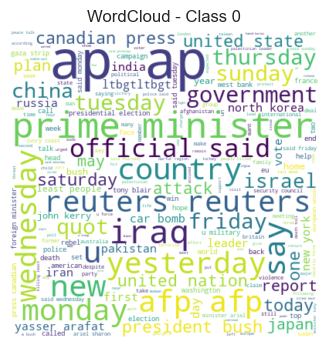

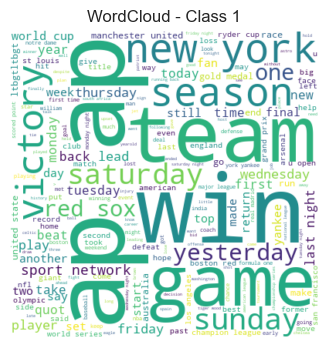

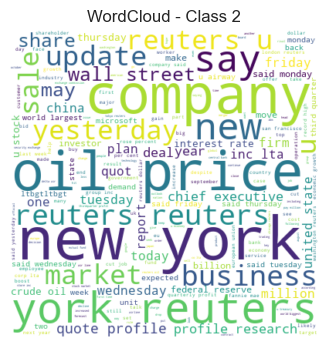

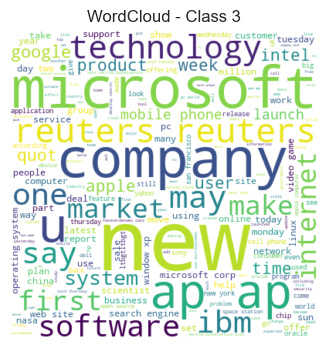

In [13]:
labels = sorted(df['label'].unique())
for lab in labels:
    text = " ".join(df[df['label']==lab]['clean_text'].tolist())
    wc = WordCloud(width=400, height=400, background_color="white").generate(text)
    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"WordCloud - Class {lab}")
    plt.show()


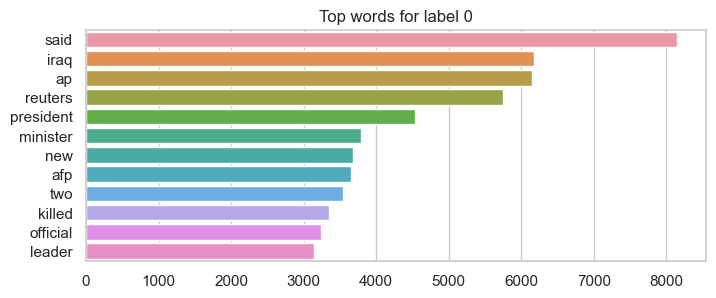

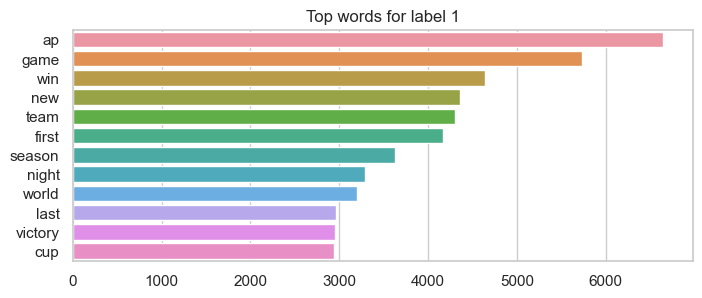

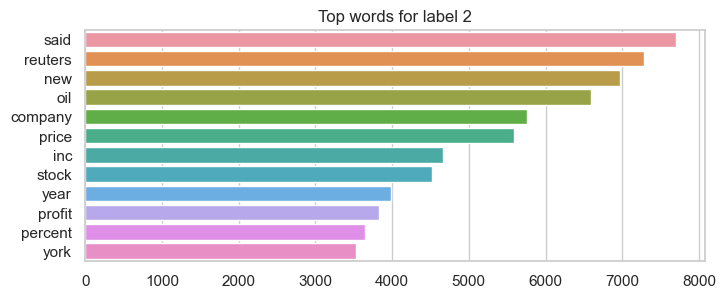

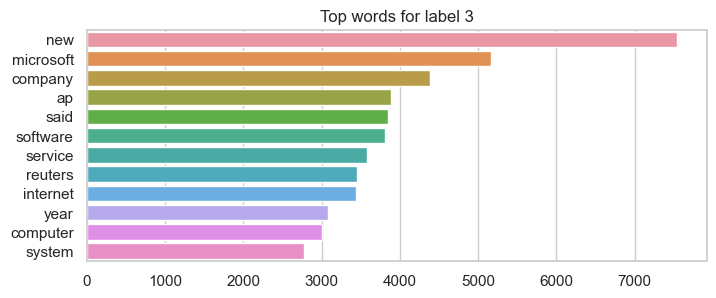

In [14]:
cv = CountVectorizer(max_features=5000, ngram_range=(1,1))
cv.fit(df['clean_text'])
feat = cv.get_feature_names_out()
X_count = cv.transform(df['clean_text'])
df_counts = pd.DataFrame(X_count.toarray(), columns=feat)
df_counts['label'] = df['label'].values

def top_n_words_for_label(label, n=10):
    s = df_counts[df_counts['label']==label].drop(columns='label').sum().sort_values(ascending=False)
    return s.head(n)

for lab in labels:
    top = top_n_words_for_label(lab, n=12)
    plt.figure(figsize=(8,3))
    sns.barplot(x=top.values, y=top.index)
    plt.title(f"Top words for label {lab}")
    plt.show()


In [15]:
# Convert to dense (may use large memory; reduce vectorizer max_features if MemoryError)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

num_classes = len(np.unique(y_train))
model_nn = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

history = model_nn.fit(
    X_train_dense, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256,
    callbacks=[es]
)

# Evaluate
loss, acc = model_nn.evaluate(X_test_dense, y_test, verbose=0)
print("NN test accuracy:", acc)


c:\Users\hazem\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.8307 - loss: 0.5527 - val_accuracy: 0.9059 - val_loss: 0.2767
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9256 - loss: 0.2150 - val_accuracy: 0.9037 - val_loss: 0.2727
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9439 - loss: 0.1634 - val_accuracy: 0.9043 - val_loss: 0.2833
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9584 - loss: 0.1189 - val_accuracy: 0.9010 - val_loss: 0.3087
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
NN test accuracy: 0.9101096987724304


In [16]:
# Example: save logistic regression and TF-IDF
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(lr, "logreg_model.joblib")
print("Saved vectorizer and model to disk.")


Saved vectorizer and model to disk.
